In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
salmansajid05_oral_diseases_path = kagglehub.dataset_download('salmansajid05/oral-diseases')
muhammadatef_oral_cancer_images_for_classification_path = kagglehub.dataset_download('muhammadatef/oral-cancer-images-for-classification')
mithileshkolhapurkar_testocc_path = kagglehub.dataset_download('mithileshkolhapurkar/testocc')

print('Data source import complete.')


Using Colab cache for faster access to the 'oral-diseases' dataset.


100%|██████████| 197M/197M [00:01<00:00, 137MB/s]

Extracting files...


100%|██████████| 66.5k/66.5k [00:00<00:00, 34.7MB/s]

Extracting files...
Data source import complete.


### Libraries and Imports 📚

In [ ]:
# Import the necessary library
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet18

## Image Copying and Counting Function 🖼️

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from PIL import Image

# Define the original directories and their corresponding class names
original_dirs = {
    'Cancer': '/kaggle/input/oral-cancer-images-for-classification/dataset/Oral Cancer photos',
    'Caries': '/kaggle/input/oral-diseases/Data caries/Data caries/caries augmented data set/preview',
    'Gingivitis': '/kaggle/input/oral-diseases/Gingivitis/Gingivitis',
    'Normal': '/kaggle/input/oral-cancer-images-for-classification/dataset/normal',
    'Tooth Discoloration': '/kaggle/input/oral-diseases/Tooth Discoloration/Tooth Discoloration /Tooth_discoloration_augmented_dataser/preview',
    'Hypodontia': '/kaggle/input/oral-diseases/hypodontia/hypodontia'
}

# Define the target base directory
base_dir = '/kaggle/working/dataset'

# Define the target structure
splits = ['train', 'val', 'test']
classes = list(original_dirs.keys())

# Create target directories
for split in splits:
    for class_name in classes:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# Initialize dictionaries to hold the counts for train, val, and test sets
class_split_counts = {class_name: {'train': 0, 'val': 0, 'test': 0} for class_name in classes}

# Function to convert palette images to RGB and copy
def convert_and_copy_image(src_path, dst_path):
    """Convert palette images to RGB/RGBA and copy to destination"""
    try:
        img = Image.open(src_path)

        # Fix for palette images with transparency
        if img.mode == 'P' and 'transparency' in img.info:
            img = img.convert('RGBA')
        elif img.mode == 'P':
            img = img.convert('RGB')

        # Save the converted image
        img.save(dst_path)

    except Exception as e:
        # If conversion fails, just copy the original
        shutil.copy(src_path, dst_path)

# Function to copy images to the target directory and count them
def copy_and_count_images(class_name, image_paths):
    # Split the data
    train_paths, test_paths = train_test_split(image_paths, test_size=0.1, random_state=42)
    train_paths, val_paths = train_test_split(train_paths, test_size=0.2, random_state=42)  # 0.2 * 0.9 = 0.18

    # Define split mappings
    split_paths = {
        'train': train_paths,
        'val': val_paths,
        'test': test_paths
    }

    # Copy images to their respective directories and count them
    for split, paths in split_paths.items():
        class_split_counts[class_name][split] = len(paths)
        for img_path in paths:
            target_path = os.path.join(base_dir, split, class_name, os.path.basename(img_path))
            # Use convert_and_copy_image instead of shutil.copy
            convert_and_copy_image(img_path, target_path)

# Traverse the original directories and gather image paths
print("Starting dataset preparation...")
for class_name, original_dir in original_dirs.items():
    print(f"Processing {class_name}...", end=" ")
    image_paths = []
    for root, dirs, files in os.walk(original_dir):
        image_paths.extend([os.path.join(root, file) for file in files if file.endswith(('.jpg', '.jpeg', '.png','.jfif','.JPG'))])
    if image_paths:
        copy_and_count_images(class_name, image_paths)
        print(f"✓ ({len(image_paths)} images)")
    else:
        print("✗ (No images found)")

print("\n" + "="*60)
print("Images have been copied and organized successfully!")
print("="*60)

Starting dataset preparation...
Processing Cancer... ✗ (No images found)
Processing Caries... ✓ (2382 images)
Processing Gingivitis... ✓ (2349 images)
Processing Normal... ✗ (No images found)
Processing Tooth Discoloration... 

## Displaying Random Images 🖼️

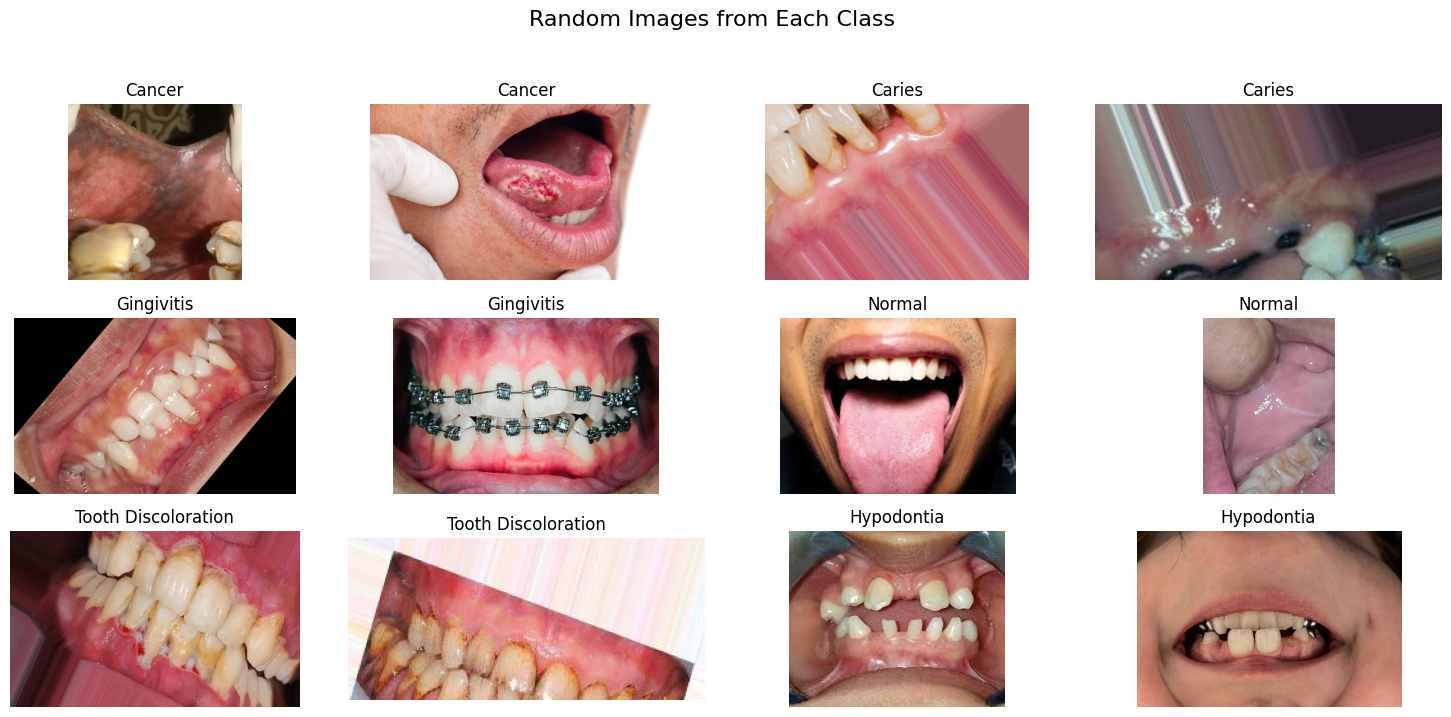

In [ ]:
# Number of images to display per class and per row
num_images_per_class = 2
num_images_per_row = 4

# Set seed for reproducibility
random.seed(42)

# Function to get random images from a directory
def get_random_images_from_dir(directory, num_images):
    all_images = [os.path.join(directory, img) for img in os.listdir(directory) if img.endswith(('.jpg', '.jpeg', '.png'))]
    if len(all_images) < num_images:
        return all_images
    return random.sample(all_images, num_images)

# Create a figure
num_rows = (len(classes) * num_images_per_class + num_images_per_row - 1) // num_images_per_row  # Calculate number of rows needed
fig, axs = plt.subplots(num_rows, num_images_per_row, figsize=(15, num_rows * 2.5))
fig.suptitle('Random Images from Each Class', fontsize=16)

# Flatten axs array for easier indexing
axs = axs.flatten()

# Iterate through classes and display images
image_idx = 0
for class_name in classes:
    class_dir = os.path.join(base_dir, 'train', class_name)
    random_images = get_random_images_from_dir(class_dir, num_images_per_class)

    for img_path in random_images:
        if image_idx < len(axs):
            img = Image.open(img_path)
            ax = axs[image_idx]
            ax.imshow(img)
            ax.set_title(class_name)
            ax.axis('off')
            image_idx += 1

# Hide any unused subplots
for i in range(image_idx, len(axs)):
    axs[i].axis('off')

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Data Visualization - Bar Plot 📊

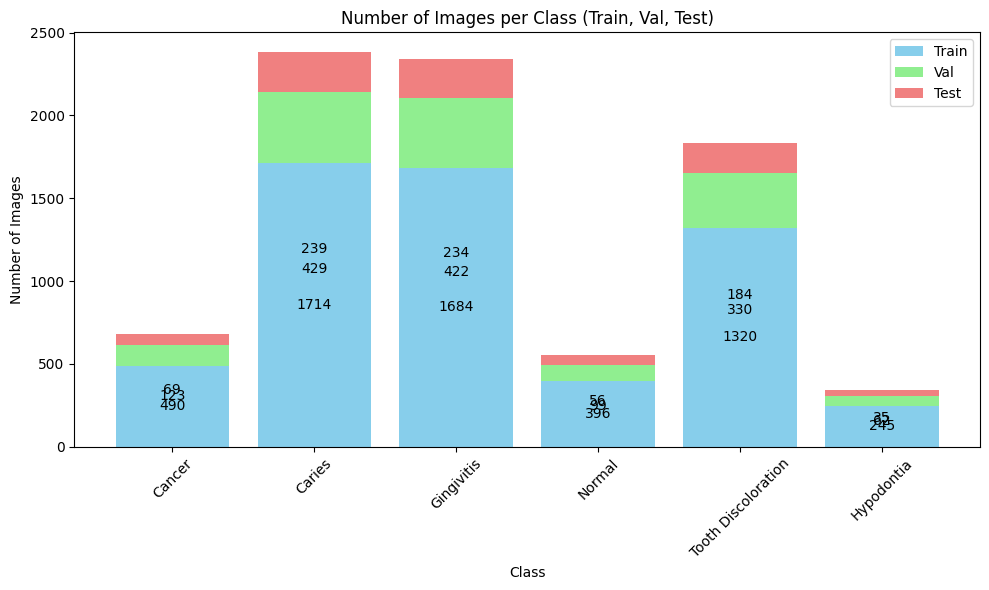

In [ ]:
# Initialize dictionaries to hold the counts for train, val, and test sets
class_split_counts = {class_name: {'train': 0, 'val': 0, 'test': 0} for class_name in classes}

# Function to count images in each split
def count_images(base_dir, class_name):
    counts = {}
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(base_dir, split, class_name)
        counts[split] = len(os.listdir(split_dir))
    return counts

# Calculate counts for each class and split
for class_name in classes:
    class_split_counts[class_name] = count_images(base_dir, class_name)

# Create lists for the bar plot
labels = classes
train_counts = [class_split_counts[class_name]['train'] for class_name in classes]
val_counts = [class_split_counts[class_name]['val'] for class_name in classes]
test_counts = [class_split_counts[class_name]['test'] for class_name in classes]

x = range(len(classes))

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar(x, train_counts, label='Train', color='skyblue')
bar2 = ax.bar(x, val_counts, bottom=train_counts, label='Val', color='lightgreen')
bar3 = ax.bar(x, test_counts, bottom=[i+j for i,j in zip(train_counts, val_counts)], label='Test', color='lightcoral')

ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_title('Number of Images per Class (Train, Val, Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

# Add data labels
for bar in bar1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval / 2, int(yval), ha='center', va='center', color='black')

for bar in bar2:
    yval = bar.get_height() + bar.get_y()
    ax.text(bar.get_x() + bar.get_width()/2, yval / 2, int(bar.get_height()), ha='center', va='center', color='black')

for bar in bar3:
    yval = bar.get_height() + bar.get_y()
    ax.text(bar.get_x() + bar.get_width()/2, yval / 2, int(bar.get_height()), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


## Model Preparing and Training 🧠

In [ ]:
# Define directories
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Parameters
image_size = (128, 128)
batch_size = 16
num_epochs = 50

# Data augmentation and normalization for training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Normalization for validation and testing
val_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_transforms)
test_dataset = ImageFolder(test_dir, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
# Get number of classes
num_classes = len(train_dataset.classes)

# Use a smaller model - ResNet18
class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.model = resnet18(weights=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Initialize the model, loss function, and optimizer
model = CustomModel()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


In [ ]:
# Set environment variable to avoid threading issues
os.environ["OMP_NUM_THREADS"] = "1"

# Define the scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

# Early stopping parameters
early_stopping = True
patience = 3  # Number of epochs to wait if no improvement is observed

# Initialize early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

# Initialize lists to store losses, accuracies, and learning rates
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Variables to store y_true and y_scores for precision-recall calculation
y_true = []
y_scores = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []
    val_outputs = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
            val_outputs.extend(outputs.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_true, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Append true labels and predicted scores for precision-recall calculation
    y_true.extend(val_true)
    y_scores.extend(val_outputs)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Check for improvement in validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the model checkpoint here if you want

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping after {epoch+1} epochs.')
            early_stop = True
            break

    # LR scheduler step based on validation loss
    scheduler.step(val_loss)

    if early_stop:
        break

/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/50], Train Loss: 0.9168, Val Loss: 0.6319, Val Acc: 0.7836


/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/50], Train Loss: 0.6364, Val Loss: 0.5760, Val Acc: 0.7877


/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [14/50], Train Loss: 0.1683, Val Loss: 0.2562, Val Acc: 0.9270


/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/50], Train Loss: 0.1502, Val Loss: 0.2873, Val Acc: 0.9133


/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [16/50], Train Loss: 0.1571, Val Loss: 0.2863, Val Acc: 0.9126
Early stopping after 16 epochs.


## Model Evaluation 📉

In [ ]:
# Test the model
model.eval()
test_preds = []
test_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_true, test_preds)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9376


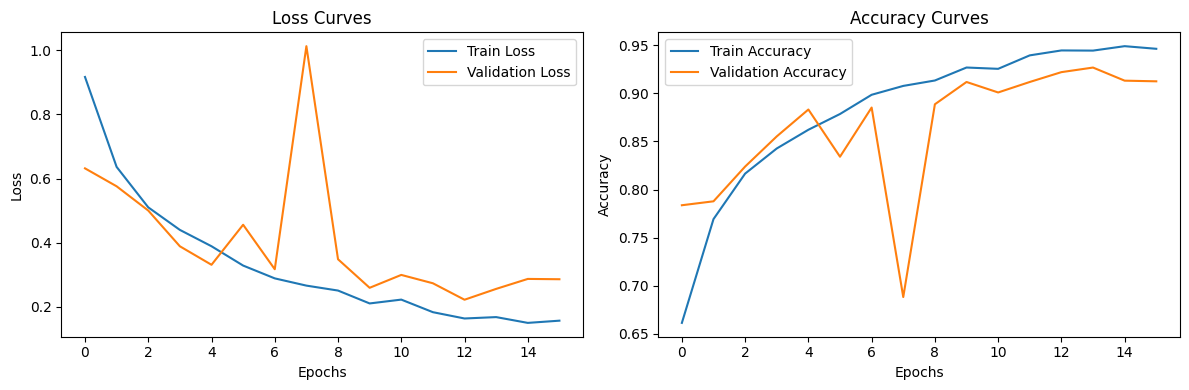

In [ ]:
# Plotting loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plotting loss
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plotting accuracy
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Generate classification report
class_names = test_dataset.classes
report = classification_report(test_true, test_preds, target_names=class_names)

# Display classification report
print("Classification Report:")
print(report)

Classification Report:
                     precision    recall  f1-score   support

             Cancer       0.85      0.84      0.85        69
             Caries       0.91      1.00      0.95       239
         Gingivitis       0.97      0.97      0.97       234
         Hypodontia       0.85      0.83      0.84        35
             Normal       0.86      0.77      0.81        56
Tooth Discoloration       1.00      0.93      0.97       184

           accuracy                           0.94       817
          macro avg       0.91      0.89      0.90       817
       weighted avg       0.94      0.94      0.94       817



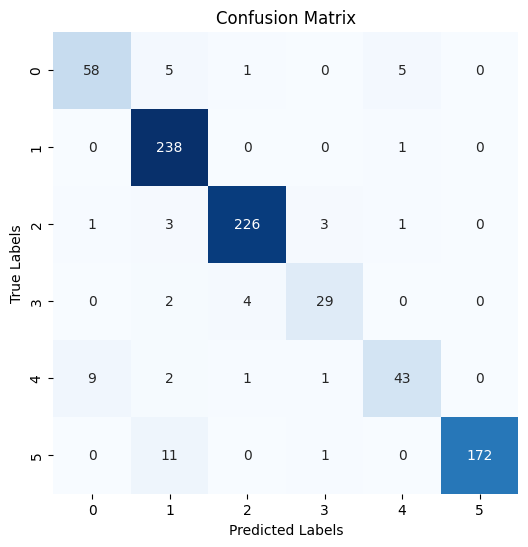

In [ ]:
# Get predictions for the test set
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculate confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

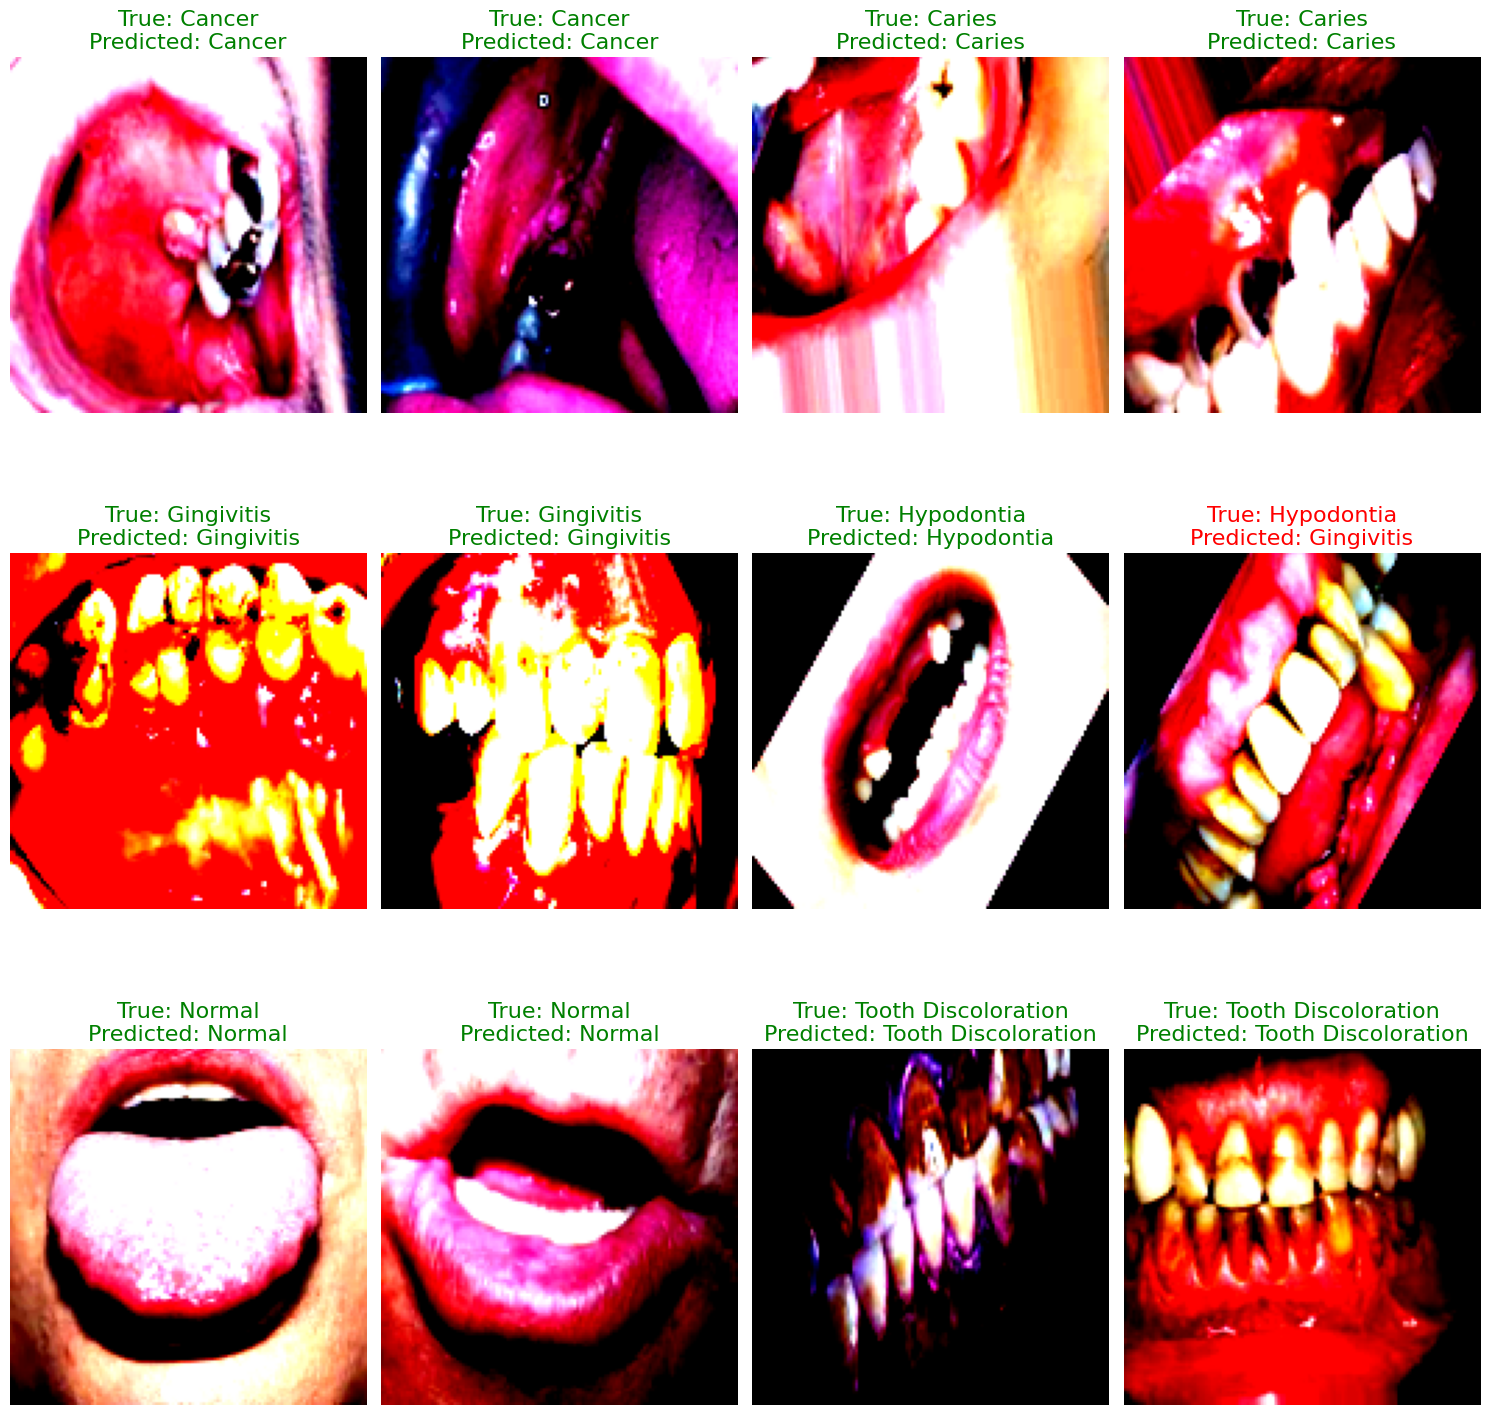

In [ ]:
# Set seed for reproducibility
random.seed(42)

# Function to display random images with true and predicted classes
def display_random__predicted_images(model, test_loader, class_names, num_images_per_class=5):
    model.eval()
    plt.figure(figsize=(15, 30))
    images_so_far = 0
    class_counts = {classname: 0 for classname in class_names}
    shown_images = []

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                true_class_name = class_names[labels[j].item()]
                predicted_class_name = class_names[preds[j].item()]

                if class_counts[true_class_name] < num_images_per_class and (true_class_name, j) not in shown_images:
                    images_so_far += 1
                    ax = plt.subplot(len(class_names), num_images_per_class * 2, images_so_far)
                    ax.axis('off')
                    if true_class_name == predicted_class_name:
                        title_color = 'green'
                    else:
                        title_color = 'red'
                    ax.set_title(f'True: {true_class_name}\nPredicted: {predicted_class_name}', fontsize=16, color=title_color)
                    plt.imshow(inputs.cpu().data[j].permute(1, 2, 0))
                    class_counts[true_class_name] += 1
                    shown_images.append((true_class_name, j))

                if images_so_far >= len(class_names) * num_images_per_class:
                    return

# Display random predicted images
display_random__predicted_images(model, test_loader, class_names, num_images_per_class=2)
plt.tight_layout()
plt.show()

In [ ]:
!pip install grad-cam -q

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Set seed for reproducibility
random.seed(42)

def visualize_grad_cam(image_paths, model, device, class_names):
    """
    Visualizes the Grad-CAM for a list of images and model.

    Parameters:
    - image_paths (list of str): List of paths to the input images.
    - model (torch.nn.Module): The pre-trained model.
    - device (torch.device): The device to run the model on (CPU or CUDA).
    - class_names (list of str): List of class names.

    Returns:
    - None: Displays the Grad-CAM visualization.
    """
    num_images = len(image_paths)
    num_rows = num_images // 2

    plt.figure(figsize=(20, 5 * num_rows))

    for idx, image_path in enumerate(image_paths):
        # Load and preprocess the image
        input_image = Image.open(image_path).convert('RGB')
        preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        input_tensor = preprocess(input_image).unsqueeze(0).to(device)

        # Access the appropriate layer in the model
        target_layer = model.model.layer4[-1]

        # Create an instance of Grad-CAM
        grad_cam = GradCAM(model=model, target_layers=[target_layer])

        # Generate the Grad-CAM
        grayscale_cam = grad_cam(input_tensor=input_tensor)[0]

        # Convert the input image to numpy array and scale to [0, 1]
        input_image_np = np.array(input_image.resize((224, 224))) / 255.0

        # Convert the grayscale cam to an RGB image
        visualization = show_cam_on_image(input_image_np, grayscale_cam, use_rgb=True)

        # Get the predicted class
        model.eval()
        with torch.no_grad():
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            predicted_class = class_names[predicted.item()]

        # Get the true class from the image path
        true_class = os.path.basename(os.path.dirname(image_path))

        # Determine title color based on correct or incorrect prediction
        if true_class == predicted_class:
            title_color = 'green'
        else:
            title_color = 'red'

        # Plot the original image with true class
        plt.subplot(num_rows, 4, 2 * idx + 1)
        plt.imshow(input_image_np)
        plt.title(f'True: {true_class}', fontsize=24, color=title_color)
        plt.axis('off')

        # Plot the Grad-CAM visualization with predicted class
        plt.subplot(num_rows, 4, 2 * idx + 2)
        plt.imshow(visualization)
        plt.title(f'Predicted: {predicted_class}', fontsize=24, color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def get_random_images_from_folders(base_folder, num_images_per_folder=2):
    """
    Gets a specified number of random images from each subfolder.

    Parameters:
    - base_folder (str): The base folder containing subfolders with images.
    - num_images_per_folder (int): Number of random images to select from each subfolder.

    Returns:
    - list of str: List of paths to the randomly selected images.
    """
    image_paths = []
    subfolders = [f.path for f in os.scandir(base_folder) if f.is_dir()]
    for subfolder in subfolders:
        images = [os.path.join(subfolder, f) for f in os.listdir(subfolder) if f.endswith(('.jpg', '.jpeg', '.png'))]
        image_paths.extend(random.sample(images, min(num_images_per_folder, len(images))))
    return image_paths

# Get random images from the test folder
base_test_folder = '/kaggle/working/dataset/test'
random_images = get_random_images_from_folders(base_test_folder, num_images_per_folder=2)

# Visualize Grad-CAM for the selected images
visualize_grad_cam(random_images, model, device, class_names)

In [ ]:
import os
import torch
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

def predict_folder(folder_path, model, device, class_names, save_results=True):
    """
    Predict classes for all images in a folder.

    Parameters:
    - folder_path: Path to folder containing images
    - model: Trained PyTorch model
    - device: torch.device (cpu or cuda)
    - class_names: List of class names
    - save_results: Whether to save results to CSV (default: True)

    Returns:
    - results: List of dictionaries with predictions
    """

    # Preprocessing
    preprocess = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # Get all image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.jfif', '.gif']
    image_files = [f for f in os.listdir(folder_path)
                   if os.path.splitext(f)[1].lower() in image_extensions]

    if len(image_files) == 0:
        print(f"No images found in {folder_path}")
        return []

    print(f"Found {len(image_files)} images. Starting prediction...\n")

    results = []
    model.eval()

    # Predict each image
    for img_file in tqdm(image_files, desc="Processing"):
        img_path = os.path.join(folder_path, img_file)

        try:
            # Load and preprocess image
            image = Image.open(img_path).convert('RGB')

            # Handle palette images
            if image.mode == 'P':
                image = image.convert('RGB')

            input_tensor = preprocess(image).unsqueeze(0).to(device)

            # Predict
            with torch.no_grad():
                outputs = model(input_tensor)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                confidence, predicted = torch.max(probabilities, 1)

            predicted_class = class_names[predicted.item()]
            confidence_score = confidence.item() * 100

            # Store result
            result = {
                'image_name': img_file,
                'predicted_class': predicted_class,
                'confidence': confidence_score
            }
            results.append(result)

        except Exception as e:
            print(f"Error processing {img_file}: {str(e)}")
            continue

    # Print summary
    print(f"\n{'='*60}")
    print(f"Prediction Complete!")
    print(f"{'='*60}")
    print(f"Total images processed: {len(results)}")
    print(f"{'='*60}\n")

    # Display results
    for i, result in enumerate(results, 1):
        print(f"{i}. {result['image_name']:30s} -> {result['predicted_class']:20s} ({result['confidence']:.2f}%)")

    # Save to CSV
    if save_results:
        import pandas as pd
        df = pd.DataFrame(results)
        output_file = 'predictions.csv'
        df.to_csv(output_file, index=False)
        print(f"\n✅ Results saved to: {output_file}")

    return results


# How to use:
# results = predict_folder('/path/to/image/folder', model, device, class_names)


In [ ]:
# Predict all images in a folder
folder_path = '/kaggle/input/testocc'
results = predict_folder(folder_path, model, device, class_names)

# Access individual results
for result in results:
    print(f"{result['image_name']}: {result['predicted_class']} - {result['confidence']:.2f}%")


Found 12 images. Starting prediction...



Processing: 100%|██████████| 12/12 [00:00<00:00, 143.95it/s]


Prediction Complete!
Total images processed: 12

1. n2.jfif                        -> Normal               (69.75%)
2. oc1.jfif                       -> Cancer               (99.70%)
3. dc1.jfif                       -> Caries               (98.15%)
4. gg2.jfif                       -> Gingivitis           (99.63%)
5. oc2.jfif                       -> Cancer               (97.11%)
6. tc2.jfif                       -> Tooth Discoloration  (94.21%)
7. h2.jfif                        -> Gingivitis           (73.23%)
8. dc2.jfif                       -> Caries               (96.91%)
9. n1.jfif                        -> Cancer               (78.71%)
10. tc1.jfif                       -> Hypodontia           (63.33%)
11. h1.jfif                        -> Caries               (52.89%)
12. gg1.jfif                       -> Gingivitis           (98.35%)

✅ Results saved to: predictions.csv
n2.jfif: Normal - 69.75%
oc1.jfif: Cancer - 99.70%
dc1.jfif: Caries - 98.15%
gg2.jfif: Gingivitis - 99.63%